# Análise de Replay de Mercado Estático

Este notebook gera um gráfico de candles para um dia específico e, em seguida, analisa cada candle para gerar um relatório de todas as sugestões de operação que o modelo de IA teria fornecido.

**Funcionalidades:**
- Gera um gráfico completo para um dia ou para um período parcial do dia.
- Exibe o gráfico com candles de M5, médias móveis e **setas indicando os sinais de Compra/Venda**.
- Apresenta um relatório detalhado com todas as operações sugeridas.
- **Exporta um relatório completo (gráfico + tabela) em um único arquivo HTML**.

### Passo 1: Importações

In [1]:
import yaml
import logging
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import pytz
import MetaTrader5 as mt5
import mplfinance as mpf
import sys
import base64
from io import BytesIO
import importlib

# Adiciona a pasta 'src' ao path
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.strategies.lstm import KerasLSTMWrapper

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

### Passo 2: Configuração da Análise

Recebe os parâmetros para execução dos testes e carrega as configurações do main.yaml.

**Ações:** Defina as variáveis `TICKER`, `REPLAY_DATETIME_STR`.

In [2]:
# --- PARÂMETROS DE ENTRADA ---
TICKER = "WDO$"  # Ativo para o replay (deve estar no main.yaml)
REPLAY_DATETIME_STR = "2025-10-10" # Data ('YYYY-MM-DD') ou Data e Hora ('YYYY-MM-DD HH:MM')
# ---------------------------

# Carrega as configurações
with open(project_root / "configs/main.yaml", "r") as file:
    config = yaml.safe_load(file)

asset_config = next((asset for asset in config['assets'] if asset['ticker'] == TICKER), None)
if not asset_config:
    raise ValueError(f"Ticker '{TICKER}' não encontrado em configs/main.yaml.")

print(f"Configurado para análise do ativo '{TICKER}' em '{REPLAY_DATETIME_STR}'.")

Configurado para análise do ativo 'WDO$' em '2025-10-10'.


### Passo 3: Geração do Gráfico limpo.

2025-10-12 13:58:32,649 - INFO - Gerando gráfico limpo para WDO$ em 2025-10-10.
2025-10-12 13:58:32,892 - INFO - Conectando ao MT5 para buscar candles de M5 para WDO$...
2025-10-12 13:58:32,947 - INFO - 228 candles de M5 carregados.
2025-10-12 13:58:32,949 - INFO - Gerando gráfico estático...


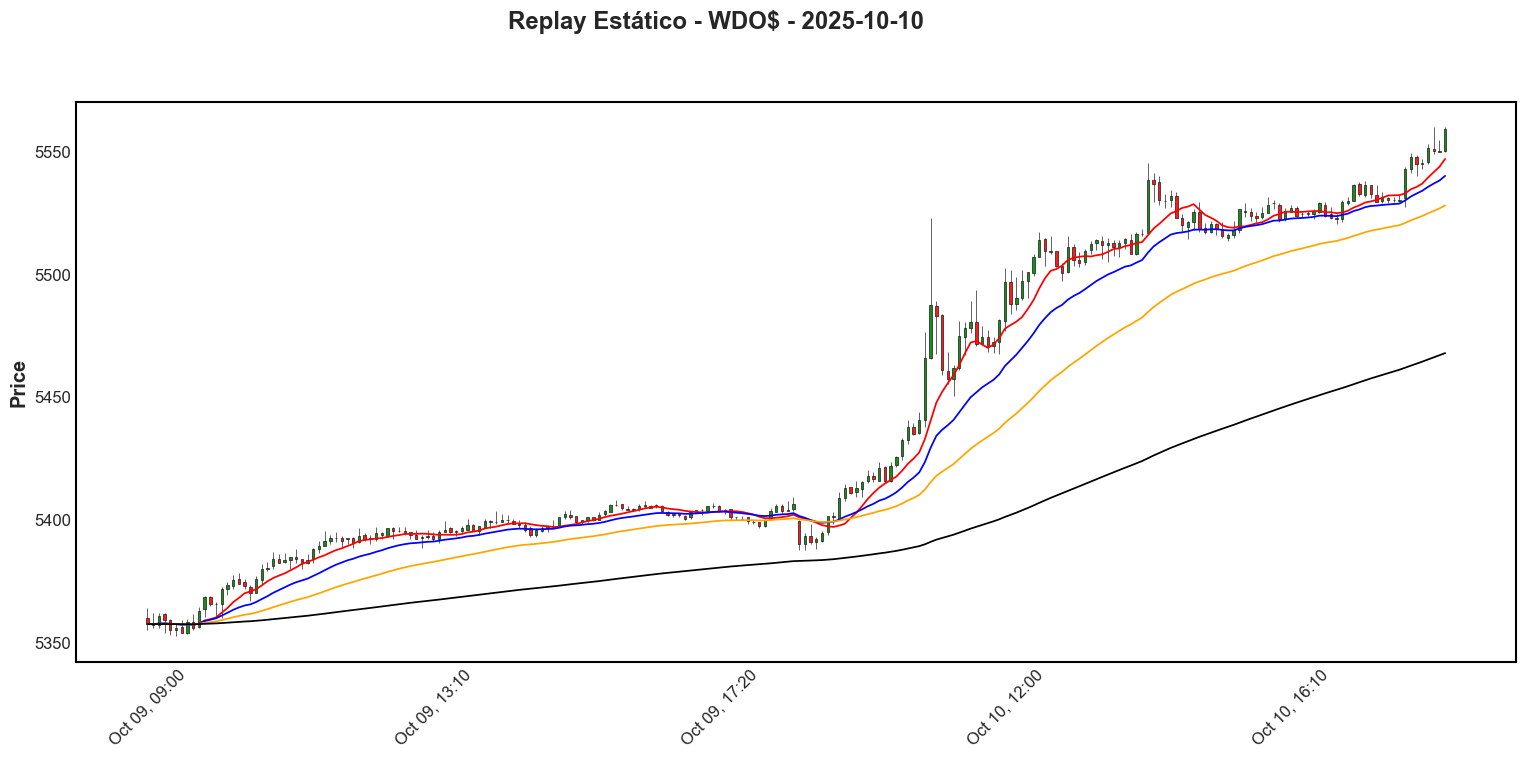

In [4]:
def generate_clean_graph(ticker, datetime_str):
    logging.info(f"Gerando gráfico limpo para {ticker} em {datetime_str}.")
    # Aqui você implementaria a lógica para gerar o gráfico limpo

    # 1. Processar data e hora
    try:
        end_dt_obj = datetime.strptime(datetime_str, '%Y-%m-%d %H:%M')
        start_dt_obj = end_dt_obj.replace(hour=0, minute=0, second=0)
    except ValueError:
        start_dt_obj = datetime.strptime(datetime_str, '%Y-%m-%d')
        end_dt_obj = start_dt_obj.replace(hour=23, minute=59, second=59)    

    timezone = pytz.timezone("Etc/UTC")
    start_time_utc = timezone.localize(start_dt_obj)
    end_time_utc = timezone.localize(end_dt_obj)

    # Inicia o gráfico no dia anterior
    start_time_utc = start_time_utc - timedelta(days=1)

    # 2. Buscar dados de candles M5
    logging.info(f"Conectando ao MT5 para buscar candles de M5 para {ticker}...")
    if not mt5.initialize():
        logging.error(f"Falha na inicialização do MT5: {mt5.last_error()}")
        return
    
    rates = mt5.copy_rates_range(ticker, mt5.TIMEFRAME_M5, start_time_utc, end_time_utc)
    mt5.shutdown()

    if rates is None or len(rates) == 0:
        logging.error("Nenhum dado de candle encontrado para o período.")
        return
    
    candles_df = pd.DataFrame(rates)
    candles_df['time'] = pd.to_datetime(candles_df['time'], unit='s')
    candles_df.set_index('time', inplace=True)
    candles_df.rename(columns={'tick_volume': 'volume'}, inplace=True)
    logging.info(f"{len(candles_df)} candles de M5 carregados.")

    # 3. Calcular indicadores
    candles_df['sma9'] = candles_df['close'].rolling(window=9).mean()
    candles_df['ema21'] = candles_df['close'].ewm(span=21, adjust=False).mean()
    candles_df['ema50'] = candles_df['close'].ewm(span=50, adjust=False).mean()
    candles_df['ema200'] = candles_df['close'].ewm(span=200, adjust=False).mean()

    # 4. Gerar Gráfico
    chart_style = mpf.make_mpf_style(base_mpf_style='default', marketcolors=mpf.make_marketcolors(up='g', down='r'), facecolor='white', gridstyle='-')
    addplots = [
        mpf.make_addplot(candles_df['sma9'], color='red'),
        mpf.make_addplot(candles_df['ema21'], color='blue'),
        mpf.make_addplot(candles_df['ema50'], color='orange'),
        mpf.make_addplot(candles_df['ema200'], color='black'),
    ]
    
    logging.info("Gerando gráfico estático...")
    mpf.plot(candles_df, type='candle', style=chart_style, addplot=addplots, figsize=(20, 8), title=f"Replay Estático - {ticker} - {start_dt_obj.date()}")

generate_clean_graph(TICKER, REPLAY_DATETIME_STR)    